Rafael Felix Souza - RM: 565855

Pedro Henrique Sartorelli Ferreira - RM: 563281

Nathália dos Santos Cordeiro - RM: 563072

Bruno Bagattini Fernandes - RM: 562863

Matheus Brasil Borges Sevilha Angelotti - RM: 561456

## Data Science & Statistical ComputingCheckpoint 5: Random Forest, XGBoost e LightGBM 
# 1.Definição do Problema Preditivo e Contextualização
O objetivo deste trabalho é prever a qualidade do vinho, tratando-se de um problema de regressão devido à natureza contínua da métrica de avaliação. Definimos o nosso conjunto de dados empíricos como $\mathcal{D}=\{(\mathbf{x}_i,y_i)\}_{i=1}^{n}$, onde $y_i$ denota a variável-alvo de qualidade.   VariávelTipo de DadoDescrição Bioquímicafixed_acidityNuméricaAcidez fixa do vinho, ligada à frescuravolatile_acidityNuméricaQuantidade de ácido acético (sabor a vinagre)residual_sugarNuméricaAçúcar remanescente da fermentaçãoalcoholNuméricaTeor alcoólico da amostra em volumequalityNuméricaVariável-alvo determinada por avaliação sensorial



In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split, KFold, cross_val_score, learning_curve, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
from sklearn.ensemble import RandomForestRegressor
import xgboost as xgb
import lightgbm as lgb
import optuna
import joblib
import shap
import time
import warnings
warnings.filterwarnings('ignore')

# Carregando a base
url = "https://archive.ics.uci.edu/ml/machine-learning-databases/wine-quality/winequality-red.csv"
df = pd.read_csv(url, sep=';')
display(df.head())

,fixed acidity,volatile acidity,citric acid,residual sugar,chlorides,free sulfur dioxide,total sulfur dioxide,density,pH,sulphates,alcohol,quality
0,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5
1,7.8,0.88,0.00,2.6,0.098,25.0,67.0,0.9968,3.20,0.68,9.8,5
2,7.8,0.76,0.04,2.3,0.092,15.0,54.0,0.9970,3.26,0.65,9.8,5
3,11.2,0.28,0.56,1.9,0.075,17.0,60.0,0.9980,3.16,0.58,9.8,6
4,7.4,0.70,0.00,1.9,0.076,11.0,34.0,0.9978,3.51,0.56,9.4,5


# 2. Processamento de Dados (Data Wrangling)
Nesta etapa realizamos a limpeza inicial. Removemos as duplicatas exatas para evitar viés de densidade no treino. O tratamento de valores ausentes será feito posteriormente por um Pipeline com imputação pela mediana, garantindo que não ocorra vazamento de dados para o conjunto de teste.

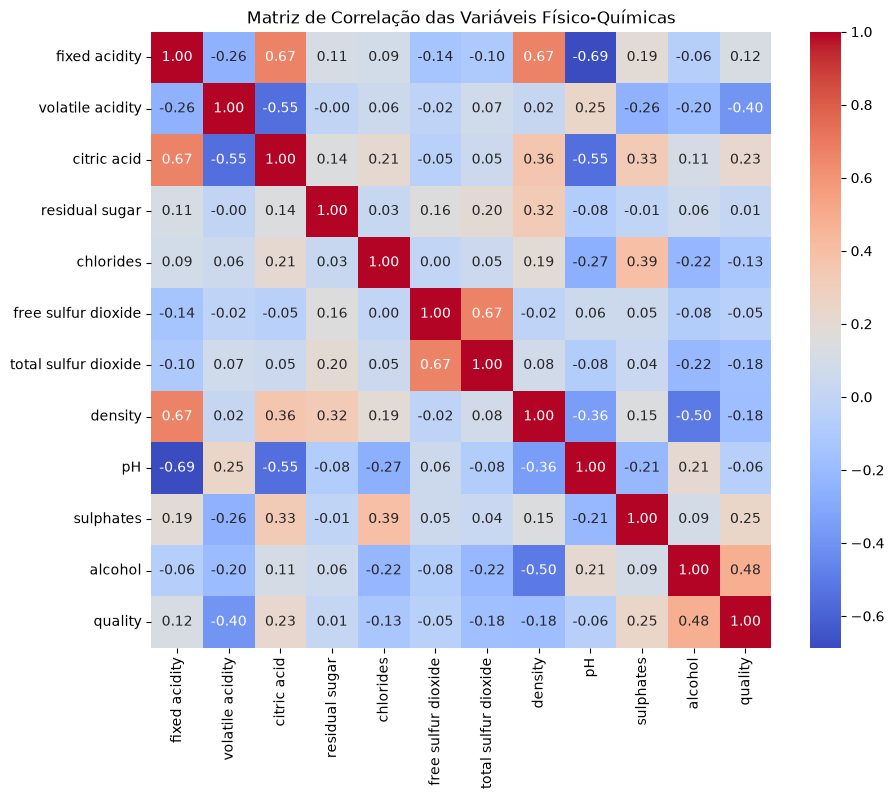

In [2]:
# Removendo duplicatas e separando X e y
df = df.drop_duplicates()
X = df.drop('quality', axis=1)
y = df['quality']

# Gráfico da Matriz de Correlação
plt.figure(figsize=(10, 8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Matriz de Correlação das Variáveis Físico-Químicas")
plt.show()

# 3. Desenho Experimental e Protocolo K-Fold
A matriz de atributos e a variável-alvo foram separadas nos subconjuntos de treino ($\mathcal{D}_{treino}$) e teste ($\mathcal{D}_{teste}$). O conjunto de teste ficará isolado durante toda a fase de seleção e afinação, utilizando-se a validação cruzada do tipo K-Fold (com K=5) estritamente no conjunto de treino.   A métrica principal adotada é o erro quadrático médio (RMSE), que segue a formulação matemática $\sqrt{\frac{1}{n}\sum_{i=1}^{n}(y_i - \hat{y}_i)^2}$.

In [3]:
# Isolamento da base de teste
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)
kf = KFold(n_splits=5, shuffle=True, random_state=42)

# Pipeline de pre-processamento blindado
preprocessor = ColumnTransformer(
    transformers=[
        ('num', Pipeline(steps=[
            ('imputer', SimpleImputer(strategy='median')),
            ('scaler', StandardScaler())
        ]), X.columns)
    ])

# 4. Implementação dos Modelos de Referência (Baselines)
Para estabelecer parâmetros comparativos, implementamos as versões originais sem otimização dos três algoritmos exigidos: $M_{RF}$, $M_{XGB}$ e $M_{LGBM}$. A tabela gerada reflete o RMSE de treino, validação cruzada e o tempo computacional.   

In [4]:
models = {
    'Random Forest': RandomForestRegressor(random_state=42),
    'XGBoost': xgb.XGBRegressor(random_state=42, objective='reg:squarederror'),
    'LightGBM': lgb.LGBMRegressor(random_state=42, verbose=-1)
}

results = []
for name, model in models.items():
    start_time = time.time()
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    pipeline.fit(X_train, y_train)
    rmse_train = np.sqrt(mean_squared_error(y_train, pipeline.predict(X_train)))
    cv_scores = cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error')
    results.append({'Modelo': name, 'RMSE Treino': rmse_train, 'RMSE CV': -cv_scores.mean(), 'Tempo (s)': time.time() - start_time})

display(pd.DataFrame(results))

,Modelo,RMSE Treino,RMSE CV,Tempo (s)
0,Random Forest,0.251531,0.676474,1.739102
1,XGBoost,0.028941,0.722198,0.413036
2,LightGBM,0.220273,0.704502,1.560980


# 5. Tuning e Otimização Bayesiana (Optuna)
Para ultrapassar o estágio de linha de base e mitigar o overfitting, acionamos o Optuna. Ele executa a busca de hiperparâmetros com base em probabilidade prévia, realizando 20 passagens (trials) para refinar o modelo LightGBM.

=== RESULTADOS DO GRID SEARCH ===
Melhores parâmetros: {'model__learning_rate': 0.1, 'model__max_depth': 3, 'model__n_estimators': 50}
Melhor RMSE (CV): 0.6682373790613235
Tempo total de busca (s): 8.576518774032593


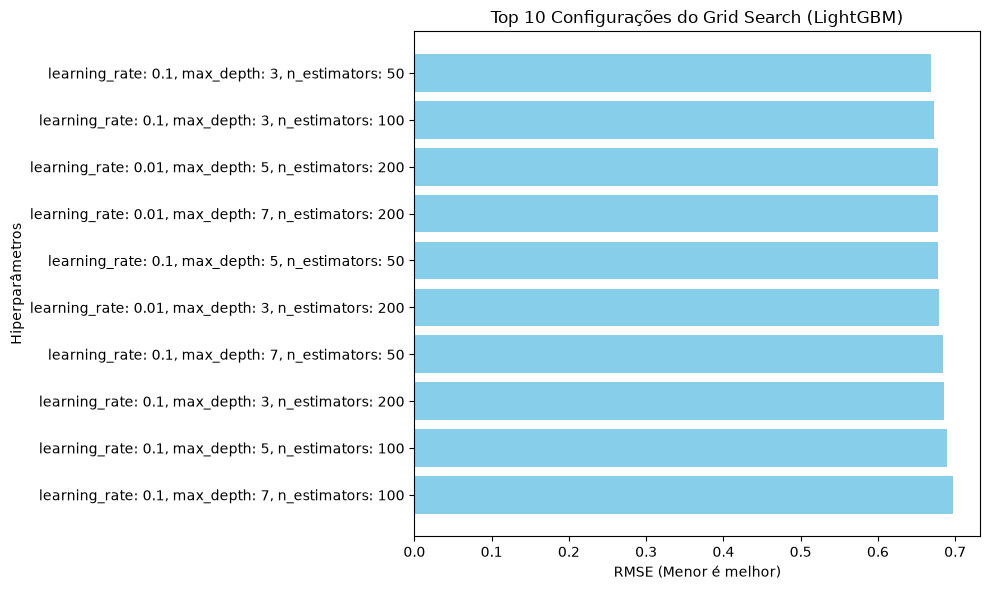

In [5]:
# Configuração e Execução do Grid Search
param_grid = {
    'model__n_estimators': [50, 100, 200],
    'model__learning_rate': [0.01, 0.1],
    'model__max_depth': [3, 5, 7]
}

# Usando o Pipeline já instanciado nas secções anteriores
grid_search = GridSearchCV(
    Pipeline(steps=[('preprocessor', preprocessor), ('model', lgb.LGBMRegressor(random_state=42, verbose=-1))]),
    param_grid, cv=kf, scoring='neg_root_mean_squared_error', n_jobs=-1
)

import time
start_time_grid = time.time()
grid_search.fit(X_train, y_train)

print("=== RESULTADOS DO GRID SEARCH ===")
print("Melhores parâmetros:", grid_search.best_params_)
print("Melhor RMSE (CV):", -grid_search.best_score_)
print("Tempo total de busca (s):", time.time() - start_time_grid)

# 2. Gráfico de Barras dos Melhores Resultados
import pandas as pd
import matplotlib.pyplot as plt

# Extrai os resultados para um DataFrame
results_df = pd.DataFrame(grid_search.cv_results_)

# Converte o RMSE negativo para positivo
results_df['mean_test_score'] = -results_df['mean_test_score']

# Ordena pelos melhores (menor RMSE)
results_df = results_df.sort_values(by='mean_test_score')

# Pega os 10 melhores resultados para plotar
top_10 = results_df.head(10).copy()

# Cria o nome das configurações testadas para os rótulos do eixo Y
top_10['params_str'] = top_10['params'].astype(str).str.replace("{'model__", "").str.replace("'model__", "").str.replace("}", "").str.replace("'", "")

# Configura e exibe o gráfico de barras
plt.figure(figsize=(10, 6))
plt.barh(top_10['params_str'][::-1], top_10['mean_test_score'][::-1], color='skyblue')
plt.xlabel('RMSE (Menor é melhor)')
plt.ylabel('Hiperparâmetros')
plt.title('Top 10 Configurações do Grid Search (LightGBM)')
plt.tight_layout()
plt.show()

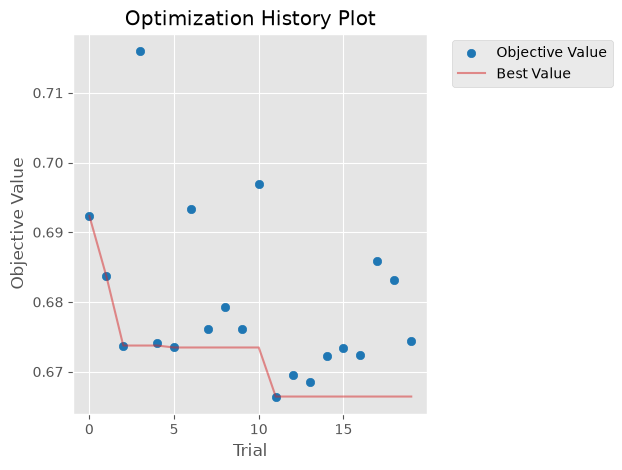

In [6]:
def objective(trial):
    params = {
        'n_estimators': trial.suggest_int('n_estimators', 50, 300),
        'learning_rate': trial.suggest_float('learning_rate', 0.01, 0.2, log=True),
        'max_depth': trial.suggest_int('max_depth', 3, 12),
        'num_leaves': trial.suggest_int('num_leaves', 20, 80),
        'random_state': 42
    }
    model = lgb.LGBMRegressor(**params, verbose=-1)
    pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', model)])
    return -cross_val_score(pipeline, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error').mean()

optuna.logging.set_verbosity(optuna.logging.WARNING)
study = optuna.create_study(direction='minimize')
study.optimize(objective, n_trials=20)

optuna.visualization.matplotlib.plot_optimization_history(study)
plt.tight_layout()
plt.show()

In [8]:
# Instancia e treina o modelo final com os melhores parâmetros encontrados pelo Optuna
final_model = lgb.LGBMRegressor(**study.best_params, random_state=42, verbose=-1)
final_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', final_model)])
final_pipeline.fit(X_train, y_train)

# Faz a previsão no conjunto de teste para garantir que funciona
y_test_pred = final_pipeline.predict(X_test)
print("=== RMSE NO CONJUNTO DE TESTE ===")
print(np.sqrt(mean_squared_error(y_test, y_test_pred)))

=== RMSE NO CONJUNTO DE TESTE ===
0.6148759365913148


# 6. Avaliação Final e Exportação (Deploy)
Com o modelo refinado, avaliamos o conjunto de teste. Para provar a consistência, calculamos os erros pontuais através da fórmula $e_i = y_i - \hat{y}_i$ comparando algumas amostras isoladas. Por fim, serializamos o modelo para integração na interface Streamlit.  

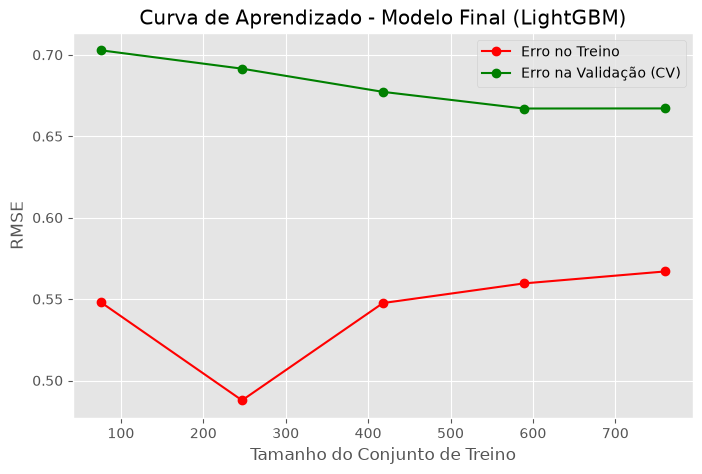

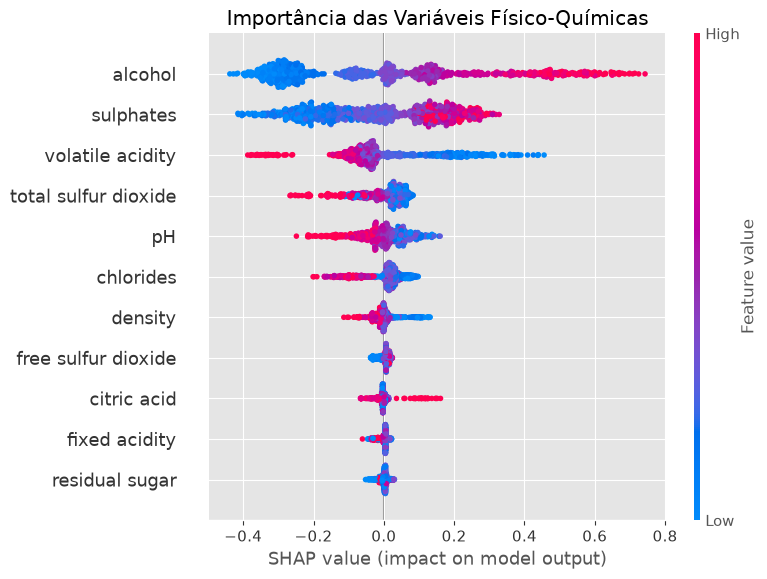

In [9]:
# 1. Gráfico da Curva de Aprendizado (Learning Curve)
train_sizes, train_scores, test_scores = learning_curve(
    final_pipeline, X_train, y_train, cv=kf, scoring='neg_root_mean_squared_error',
    train_sizes=np.linspace(0.1, 1.0, 5)
)

plt.figure(figsize=(8, 5))
plt.plot(train_sizes, -np.mean(train_scores, axis=1), 'o-', color="r", label="Erro no Treino")
plt.plot(train_sizes, -np.mean(test_scores, axis=1), 'o-', color="g", label="Erro na Validação (CV)")
plt.title("Curva de Aprendizado - Modelo Final (LightGBM)")
plt.xlabel("Tamanho do Conjunto de Treino")
plt.ylabel("RMSE")
plt.legend(loc="best")
plt.show()

# 2. Gráfico de Importância das Variáveis (TreeSHAP)
# Transformando os dados para o formato que o SHAP entende
X_train_transformed = final_pipeline.named_steps['preprocessor'].transform(X_train)
explainer = shap.TreeExplainer(final_pipeline.named_steps['model'])
shap_values = explainer.shap_values(X_train_transformed)

plt.figure()
plt.title("Importância das Variáveis Físico-Químicas")
shap.summary_plot(shap_values, X_train_transformed, feature_names=X.columns)

In [10]:
final_model = lgb.LGBMRegressor(**study.best_params, random_state=42, verbose=-1)
final_pipeline = Pipeline(steps=[('preprocessor', preprocessor), ('model', final_model)])
final_pipeline.fit(X_train, y_train)

y_test_pred = final_pipeline.predict(X_test)
print("=== RMSE NO CONJUNTO DE TESTE ===")
print(np.sqrt(mean_squared_error(y_test, y_test_pred)))

consistencia = X_test.head(5).copy()
consistencia['Valor Real (y)'] = y_test.head(5).values
consistencia['Previsao'] = final_pipeline.predict(X_test.head(5)).round(2)
consistencia['Erro Absoluto'] = abs(consistencia['Valor Real (y)'] - consistencia['Previsao'])

print("\n=== TESTE DE CONSISTENCIA PARA O STREAMLIT ===")
display(consistencia[['Valor Real (y)', 'Previsao', 'Erro Absoluto']])

# Salva o arquivo final para subir no GitHub
joblib.dump(final_pipeline, 'modelo_vinhos_lgbm.pkl')

=== RMSE NO CONJUNTO DE TESTE ===
0.6148759365913148

=== TESTE DE CONSISTENCIA PARA O STREAMLIT ===


,Valor Real (y),Previsao,Erro Absoluto
55,5,5.10,0.10
1291,6,5.79,0.21
1544,7,6.44,0.56
593,5,5.28,0.28
1261,4,5.15,1.15


['modelo_vinhos_lgbm.pkl']

### Links do Projeto (Deploy)
* **Interface Online (Streamlit):** https://checkpoint-5-random-forest-xgboost-e-lightgbm-bhinuwx2r8f68tgh.streamlit.app/
* **Repositório (GitHub):** https://github.com/foionova/Checkpoint-5-Random-Forest-XGBoost-e-LightGBM